In [1]:
%cd /workspace

/workspace


/venv/main/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import torch

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(device)

cuda


In [3]:
import polars as pl
from pathlib import Path
from tqdm.auto import tqdm


def extract_features(path: Path) -> pl.DataFrame:
    """
    Ekstrakcja zagregowanych cech z danych keystroke.

    Dla każdej sesji pisania obliczamy statystyki:
    - mean, std, median, quantiles dla czasów
    - cechy dla popularnych digrafów (np. 'th', 'he', 'er')
    """

    print(f"Loading {path}...")
    df = pl.read_parquet(path)

    print("Converting types...")
    df = df.with_columns(
        [
            pl.col("PRESS_TIME").cast(pl.Float64, strict=False),
            pl.col("RELEASE_TIME").cast(pl.Float64, strict=False),
            pl.col("KEYSTROKE_ID").cast(pl.Int64, strict=False),
            pl.col("LETTER").cast(pl.Utf8).str.to_lowercase().alias("letter_lower"),
        ]
    )

    print("Sorting...")
    df = df.sort(["TEST_SECTION_ID", "KEYSTROKE_ID"])

    print("Computing timing features...")
    df = df.with_columns(
        [
            # Hold time = czas trzymania klawisza
            (pl.col("RELEASE_TIME") - pl.col("PRESS_TIME")).alias("hold_time"),
            # Flight time = czas "lotu" między klawiszami
            (
                pl.col("PRESS_TIME").shift(-1).over("TEST_SECTION_ID")
                - pl.col("RELEASE_TIME")
            ).alias("flight_time"),
            # IKI = inter-key interval
            (
                pl.col("PRESS_TIME")
                - pl.col("PRESS_TIME").shift(1).over("TEST_SECTION_ID")
            ).alias("iki"),
            # Digraph (para liter)
            (
                pl.col("letter_lower")
                + pl.col("letter_lower").shift(-1).over("TEST_SECTION_ID")
            ).alias("digraph"),
            (
                pl.col("PRESS_TIME").shift(-1).over("TEST_SECTION_ID")
                - pl.col("PRESS_TIME")
            ).alias("digraph_time"),
        ]
    )

    # Filtruj outliers
    df = df.with_columns(
        [
            pl.when(pl.col("hold_time").is_between(0, 2000))
            .then(pl.col("hold_time"))
            .otherwise(None)
            .alias("hold_time"),
            pl.when(pl.col("flight_time").is_between(-500, 2000))
            .then(pl.col("flight_time"))
            .otherwise(None)
            .alias("flight_time"),
            pl.when(pl.col("iki").is_between(0, 2000))
            .then(pl.col("iki"))
            .otherwise(None)
            .alias("iki"),
            pl.when(pl.col("digraph_time").is_between(0, 2000))
            .then(pl.col("digraph_time"))
            .otherwise(None)
            .alias("digraph_time"),
        ]
    )

    # Popularne digrafy w języku angielskim
    common_digraphs = [
        "th",
        "he",
        "er",
        "in",
        "on",
        "an",
        "re",
        "nd",
        "at",
        "en",
        "es",
        "ou",
        "to",
        "it",
        "is",
        "or",
        "ti",
        "as",
        "te",
        "et",
    ]

    print("Aggregating basic features...")
    basic_agg = df.group_by(["PARTICIPANT_ID", "TEST_SECTION_ID"]).agg(
        [
            pl.len().alias("n_keystrokes"),
            pl.col("hold_time").mean().alias("hold_mean"),
            pl.col("hold_time").std().alias("hold_std"),
            pl.col("hold_time").median().alias("hold_median"),
            pl.col("hold_time").quantile(0.25).alias("hold_q25"),
            pl.col("hold_time").quantile(0.75).alias("hold_q75"),
            pl.col("hold_time").quantile(0.1).alias("hold_q10"),
            pl.col("hold_time").quantile(0.9).alias("hold_q90"),
            pl.col("flight_time").mean().alias("flight_mean"),
            pl.col("flight_time").std().alias("flight_std"),
            pl.col("flight_time").median().alias("flight_median"),
            pl.col("flight_time").quantile(0.25).alias("flight_q25"),
            pl.col("flight_time").quantile(0.75).alias("flight_q75"),
            pl.col("iki").mean().alias("iki_mean"),
            pl.col("iki").std().alias("iki_std"),
            pl.col("iki").median().alias("iki_median"),
            pl.col("iki").quantile(0.25).alias("iki_q25"),
            pl.col("iki").quantile(0.75).alias("iki_q75"),
            (pl.col("PRESS_TIME").max() - pl.col("PRESS_TIME").min()).alias("duration"),
            (pl.col("flight_time") < 0).sum().alias("overlap_count"),
        ]
    )

    print("Computing digraph features...")
    digraph_aggs = []
    for dg in tqdm(common_digraphs, desc="Digraphs"):
        dg_agg = (
            df.filter(pl.col("digraph") == dg)
            .group_by(["PARTICIPANT_ID", "TEST_SECTION_ID"])
            .agg(
                [
                    pl.col("digraph_time").mean().alias(f"dg_{dg}_mean"),
                    pl.col("digraph_time").std().alias(f"dg_{dg}_std"),
                ]
            )
        )
        digraph_aggs.append(dg_agg)

    print("Joining features...")
    features = basic_agg
    for dg_agg in digraph_aggs:
        features = features.join(
            dg_agg, on=["PARTICIPANT_ID", "TEST_SECTION_ID"], how="left"
        )

    features = features.with_columns(
        [
            (pl.col("n_keystrokes") / (pl.col("duration") / 1000)).alias(
                "typing_speed"
            ),
            # Overlap ratio (jak często klawisze się nakładają)
            (pl.col("overlap_count") / pl.col("n_keystrokes")).alias("overlap_ratio"),
        ]
    )

    features = features.filter(pl.col("n_keystrokes") >= 20)

    print(f"Extracted {len(features):,} sessions with {features.shape[1]} features")
    return features

In [4]:
import torch.nn as nn
import torch.nn.functional as F


class MLPEncoder(nn.Module):
    """
    - Warstwy fully-connected z BatchNorm i Dropout
    - Wyjście: znormalizowany embedding
    """

    def __init__(
        self, input_dim: int, embedding_dim: int, hidden_dim: int, dropout: float
    ):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embedding_dim),
        )

    def forward(self, x):
        emb = self.net(x)
        # L2 normalization
        return F.normalize(emb, p=2, dim=1)


class KeystrokeModel(nn.Module):
    """
    Model do weryfikacji keystroke.

    Składa się z:
    1. Encoder MLP - zamienia features na embedding
    2. ArcFace head - klasyfikacja z marginesem (pomaga uczyć lepsze embeddingi)
    """

    def __init__(
        self,
        input_dim: int,
        num_classes: int,
        embedding_dim: int,
        hidden_dim: int,
        arcface_s: float = 30.0,  # scale
        arcface_m: float = 0.3,  # margin
    ):
        super().__init__()

        self.encoder = MLPEncoder(input_dim, embedding_dim, hidden_dim, dropout=0.5)

        self.arcface_s = arcface_s
        self.arcface_m = arcface_m
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)

        self.cos_m = np.cos(arcface_m)
        self.sin_m = np.sin(arcface_m)

    def get_embedding(self, x):
        return self.encoder(x)

    def forward(self, x, labels=None):
        """
        Jeśli labels podane - zwraca (logits, embedding) do treningu
        Jeśli nie - zwraca tylko embedding do inferencji
        """
        emb = self.get_embedding(x)

        if labels is not None:
            # ArcFace: dodaje margines do kąta między embeddingiem a wagą klasy
            weight_norm = F.normalize(self.weight, p=2, dim=1)
            cosine = F.linear(emb, weight_norm)
            sine = torch.sqrt(1.0 - cosine.pow(2).clamp(0, 1))

            # cos(θ + m) = cos(θ)cos(m) - sin(θ)sin(m)
            phi = cosine * self.cos_m - sine * self.sin_m

            # Tylko dla prawdziwej klasy dodajemy margines
            one_hot = F.one_hot(labels, num_classes=self.weight.size(0)).float()
            logits = (one_hot * phi) + ((1.0 - one_hot) * cosine)
            logits *= self.arcface_s

            return logits, emb

        return emb

In [5]:
import numpy as np
from torch.utils.data import Dataset


class KeystrokeDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [6]:
from torch.utils.data import Sampler
from collections import defaultdict
import random


class BalancedBatchSampler(Sampler):
    """
    Sampler który tworzy zbalansowane batche.
    Każdy batch ma P użytkowników z K próbkami każdy.
    Ważne dla contrastive learning.
    """

    def __init__(self, labels: np.ndarray, p: int, k: int):
        self.labels = labels
        self.p = p
        self.k = k

        self.label_to_indices = defaultdict(list)
        for idx, label in enumerate(labels):
            self.label_to_indices[label].append(idx)

        self.labels_with_k = [
            l for l, indices in self.label_to_indices.items() if len(indices) >= k
        ]
        self.n_batches = len(self.labels_with_k) // p

    def __iter__(self):
        random.shuffle(self.labels_with_k)
        for batch_idx in range(self.n_batches):
            batch = []
            selected_labels = self.labels_with_k[
                batch_idx * self.p : (batch_idx + 1) * self.p
            ]
            for label in selected_labels:
                indices = self.label_to_indices[label]
                selected = random.sample(indices, min(self.k, len(indices)))
                if len(selected) < self.k:
                    selected = random.choices(indices, k=self.k)
                batch.extend(selected)
            random.shuffle(batch)
            yield batch

    def __len__(self):
        return self.n_batches


In [7]:
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve


def compute_verification_metrics(
    embeddings: np.ndarray, labels: np.ndarray, n_pairs: int = 20000
):
    """
    1. Tworzy pary:
       - Genuine pairs: ta sama osoba, różne sesje
       - Impostor pairs: różne osoby
    2. Oblicza podobieństwo (cosine similarity)
    3. Liczy AUC, EER, accuracy
    """

    user_to_idx = defaultdict(list)
    for idx, user in enumerate(labels):
        user_to_idx[user].append(idx)

    users_with_multiple = [u for u in user_to_idx if len(user_to_idx[u]) >= 2]
    all_users = list(user_to_idx.keys())

    pairs = []
    pair_labels = []

    # Genuine pairs (ta sama osoba)
    for _ in range(n_pairs // 2):
        user = random.choice(users_with_multiple)
        i, j = random.sample(user_to_idx[user], 2)
        pairs.append((i, j))
        pair_labels.append(1)

    # Impostor pairs (różne osoby)
    for _ in range(n_pairs // 2):
        u1, u2 = random.sample(all_users, 2)
        i = random.choice(user_to_idx[u1])
        j = random.choice(user_to_idx[u2])
        pairs.append((i, j))
        pair_labels.append(0)

    # Cosine similarity (embeddingi są znormalizowane, więc dot product = cosine)
    similarities = np.array([np.dot(embeddings[i], embeddings[j]) for i, j in pairs])
    pair_labels = np.array(pair_labels)

    auc = roc_auc_score(pair_labels, similarities)

    fpr, tpr, thresholds = roc_curve(pair_labels, similarities)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fpr - fnr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2

    best_acc = 0
    for thresh in np.linspace(similarities.min(), similarities.max(), 100):
        preds = (similarities > thresh).astype(int)
        acc = accuracy_score(pair_labels, preds)
        if acc > best_acc:
            best_acc = acc

    return auc, best_acc, eer


def get_embeddings(model, loader, device):
    """Ekstrahuje embeddingi dla wszystkich próbek."""
    model.eval()
    all_emb = []
    all_labels = []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            emb = model.get_embedding(X)
            all_emb.append(emb.cpu().numpy())
            all_labels.append(y.numpy())

    return np.vstack(all_emb), np.concatenate(all_labels)

In [8]:
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0

    for X, y in (pbar := tqdm(loader, desc="Training", leave=False)):
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits, _ = model(X, y)
        loss = F.cross_entropy(logits, y)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    return total_loss / len(loader)

In [9]:
from sklearn.preprocessing import StandardScaler, LabelEncoder


def prepare_data():
    features = extract_features("output.parquet")

    MIN_SESSIONS = 5
    NUSERS = 2000

    # Filtruj użytkowników z min. sesjami
    user_counts = features.group_by("PARTICIPANT_ID").len()
    valid_users = user_counts.filter(pl.col("len") >= MIN_SESSIONS)["PARTICIPANT_ID"]
    features = features.filter(pl.col("PARTICIPANT_ID").is_in(valid_users))

    # Top N użytkowników
    top_users = (
        features.group_by("PARTICIPANT_ID")
        .len()
        .sort("len", descending=True)
        .head(NUSERS)["PARTICIPANT_ID"]
    )
    features = features.filter(pl.col("PARTICIPANT_ID").is_in(top_users))

    print(
        f"Using {features['PARTICIPANT_ID'].n_unique()} users, {len(features)} samples"
    )

    df = features.to_pandas()

    exclude = [
        "PARTICIPANT_ID",
        "TEST_SECTION_ID",
        "duration",
        "overlap_count",
        "n_keystrokes",
    ]
    feature_cols = [
        c
        for c in df.columns
        if c not in exclude and df[c].dtype in ["float64", "int64", "float32", "int32"]
    ]

    print(f"Using {len(feature_cols)} features")

    X = df[feature_cols].values.astype(np.float32)
    y_raw = df["PARTICIPANT_ID"].values

    X = np.where(np.isinf(X), np.nan, X)
    col_medians = np.nanmedian(X, axis=0)
    for i in range(X.shape[1]):
        mask = np.isnan(X[:, i])
        X[mask, i] = col_medians[i] if not np.isnan(col_medians[i]) else 0

    le = LabelEncoder()
    y = le.fit_transform(y_raw)

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    return X, y, feature_cols, scaler, le

In [ ]:
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split


X, y, feature_cols, scaler, le = prepare_data()

unique_users = np.unique(y)
train_users, test_users = train_test_split(unique_users, test_size=0.2, random_state=42)

train_mask = np.isin(y, train_users)
test_mask = np.isin(y, test_users)

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

# Re-encode train labels (muszą być 0..N-1)
train_le = LabelEncoder()
y_train_enc = train_le.fit_transform(y_train)
num_classes = len(train_le.classes_)

print(f"Train: {len(X_train)} samples, {num_classes} users")
print(f"Test: {len(X_test)} samples, {len(test_users)} users")

train_dataset = KeystrokeDataset(X_train, y_train_enc)
test_dataset = KeystrokeDataset(X_test, y_test)

p_identities = 32
k_samples = 4
bs = 256
train_sampler = BalancedBatchSampler(y_train_enc, p=p_identities, k=k_samples)
train_loader = DataLoader(train_dataset, batch_sampler=train_sampler)
test_loader = DataLoader(test_dataset, batch_size=bs, shuffle=False)

model = KeystrokeModel(
    input_dim=X_train.shape[1],
    num_classes=num_classes,
    embedding_dim=64,
    hidden_dim=256,
).to(device)

nepochs = 50
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=nepochs, eta_min=1e-6
)

print(f"\n{'Epoch':>5} {'Loss':>10} {'AUC':>10} {'Acc':>10} {'EER':>10}")
best_auc = 0
best_state = None

for epoch in tqdm(range(nepochs), desc="Epochs"):
    loss = train_epoch(model, train_loader, optimizer, device)
    scheduler.step()

    if (epoch + 1) % 10 == 0 or epoch == 0:
        emb, labels = get_embeddings(model, test_loader, device)
        auc, acc, eer = compute_verification_metrics(emb, labels)

        if auc > best_auc:
            best_auc = auc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        tqdm.write(
            f"{epoch + 1:>5} {loss:>10.4f} {auc:>10.4f} {acc:>10.4f} {eer:>10.4f}"
        )

model.load_state_dict(best_state)
emb, labels = get_embeddings(model, test_loader, device)
auc, acc, eer = compute_verification_metrics(emb, labels, n_pairs=50000)

print("=" * 50)
print(f"AUC-ROC: {auc:.4f}")
print(f"Accuracy: {acc * 100:.2f}%")
print(f"EER: {eer * 100:.2f}%")

Loading output.parquet...
Converting types...
Sorting...
Computing timing features...
Aggregating basic features...
Computing digraph features...


Digraphs:   0%|          | 0/20 [00:00<?, ?it/s]

Joining features...
Extracted 2,470,106 sessions with 64 features


/tmp/ipykernel_3826/4218485864.py:13: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  features = features.filter(pl.col("PARTICIPANT_ID").is_in(valid_users))
/tmp/ipykernel_3826/4218485864.py:22: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  features = features.filter(pl.col("PARTICIPANT_ID").is_in(top_users))


Using 2000 users, 30000 samples
Using 59 features
Train: 24000 samples, 1600 users
Test: 6000 samples, 400 users

Epoch       Loss        AUC        Acc        EER


...

Training:   0%|          | 0/50 [00:00<?, ?it/s]

Training:   0%|          | 0/50 [00:00<?, ?it/s]

Training:   0%|          | 0/50 [00:00<?, ?it/s]

Training:   0%|          | 0/50 [00:00<?, ?it/s]

   50    13.4970     0.9200     0.8464     0.1571
AUC-ROC: 0.9204
Accuracy: 84.63%
EER: 15.69%


In [11]:
# torch.save(model.state_dict(), "keystroke_model.pt")

In [12]:
# AUC-ROC: 0.9245
# Accuracy: 85.10%
# EER: 15.19%

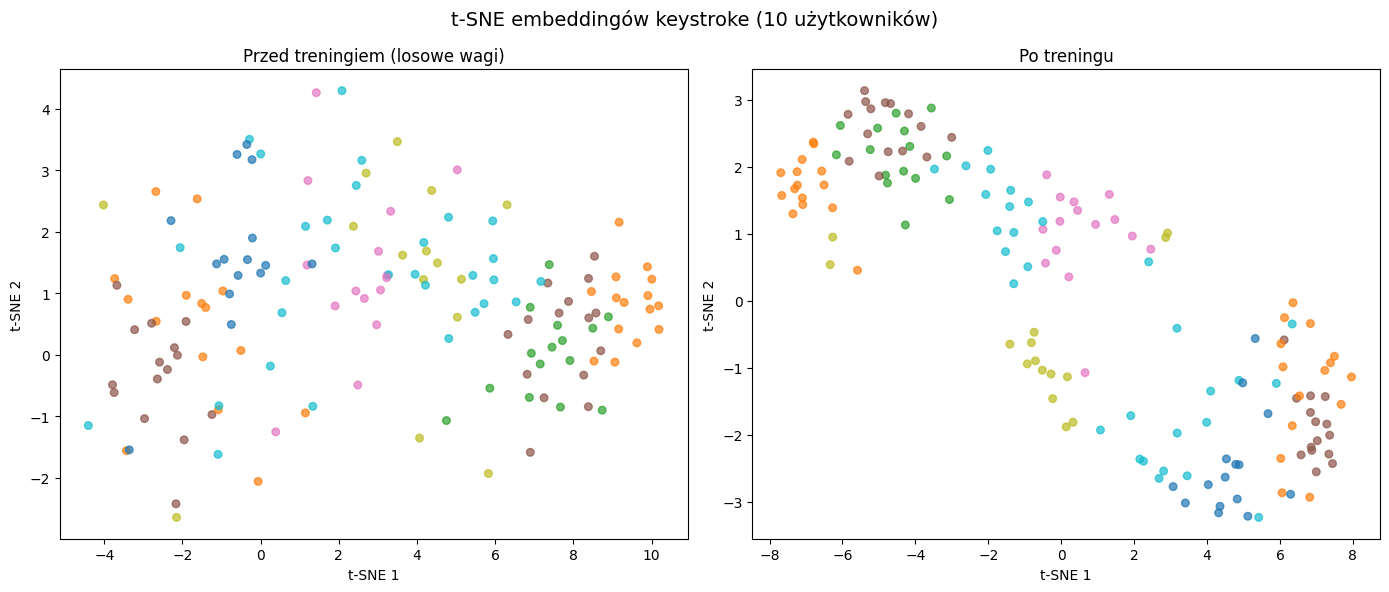

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

model_random = KeystrokeModel(
    input_dim=X_train.shape[1],
    num_classes=num_classes,
    embedding_dim=64,
    hidden_dim=256,
).to(device)
model_random.eval()

emb_before, labels_before = get_embeddings(model_random, test_loader, device)
emb_after, labels_after = get_embeddings(model, test_loader, device)

n_users = 10
unique_labels = np.unique(labels_before)[:n_users]
mask = np.isin(labels_before, unique_labels)

tsne = TSNE(n_components=2, perplexity=45, random_state=42)
emb_before_2d = tsne.fit_transform(emb_before[mask])
emb_after_2d = tsne.fit_transform(emb_after[mask])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(
    emb_before_2d[:, 0],
    emb_before_2d[:, 1],
    c=labels_before[mask],
    cmap="tab10",
    alpha=0.7,
    s=30,
)
axes[0].set_title("Przed treningiem (losowe wagi)")
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")

axes[1].scatter(
    emb_after_2d[:, 0],
    emb_after_2d[:, 1],
    c=labels_after[mask],
    cmap="tab10",
    alpha=0.7,
    s=30,
)
axes[1].set_title("Po treningu")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")

plt.suptitle(f"t-SNE embeddingów keystroke ({n_users} użytkowników)", fontsize=14)
plt.tight_layout()
plt.savefig("tsne_comparison.png", dpi=150)
plt.show()